# Iris Flower Classification

**Objective:** Train and evaluate machine learning models to classify iris flowers into one of three species — *Setosa*, *Versicolor*, or *Virginica* — based on four physical measurements (sepal length, sepal width, petal length, petal width).

**Workflow:**
1. Load the data
2. Exploratory Data Analysis (EDA)
3. Visualisations
4. Feature selection discussion
5. Train/test split
6. Train multiple classifiers
7. Evaluate & compare models
8. Declare the best model


## 1. Imports & Load Dataset

The Iris dataset ships directly with scikit-learn, so no external download is needed.

In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# scikit-learn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)

RANDOM_STATE = 42


In [2]:
# Load the Iris dataset from sklearn
iris = load_iris()

# Build a tidy DataFrame combining features + target
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 2. Exploratory Data Analysis (EDA)

We check the shape, data types, missing values, and descriptive statistics of the dataset before doing any modelling.

In [3]:
# Shape of the dataset
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")


Dataset shape: 150 rows, 5 columns


In [4]:
# Data types of each column
df.dtypes


sepal length (cm)     float64
sepal width (cm)      float64
petal length (cm)     float64
petal width (cm)      float64
species              category
dtype: object

In [5]:
# Check for null / missing values
df.isnull().sum()


sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

In [6]:
# Descriptive statistics for the numeric features
df.describe()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [7]:
# Class balance -- how many samples per species?
df['species'].value_counts()


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

**EDA takeaways:**
- The dataset has 150 rows and 5 columns (4 numeric features + 1 categorical target).
- There are no missing values, so no imputation is required.
- The dataset is perfectly balanced: 50 samples per species.
- Petal length and petal width show much larger variance (std) relative to their mean than the sepal measurements, hinting they may be more discriminative between species — we investigate this visually next.

## 3. Visualisations

We use a pairplot to see how each pair of features separates the three species, and box plots to see the spread of each individual feature by species.

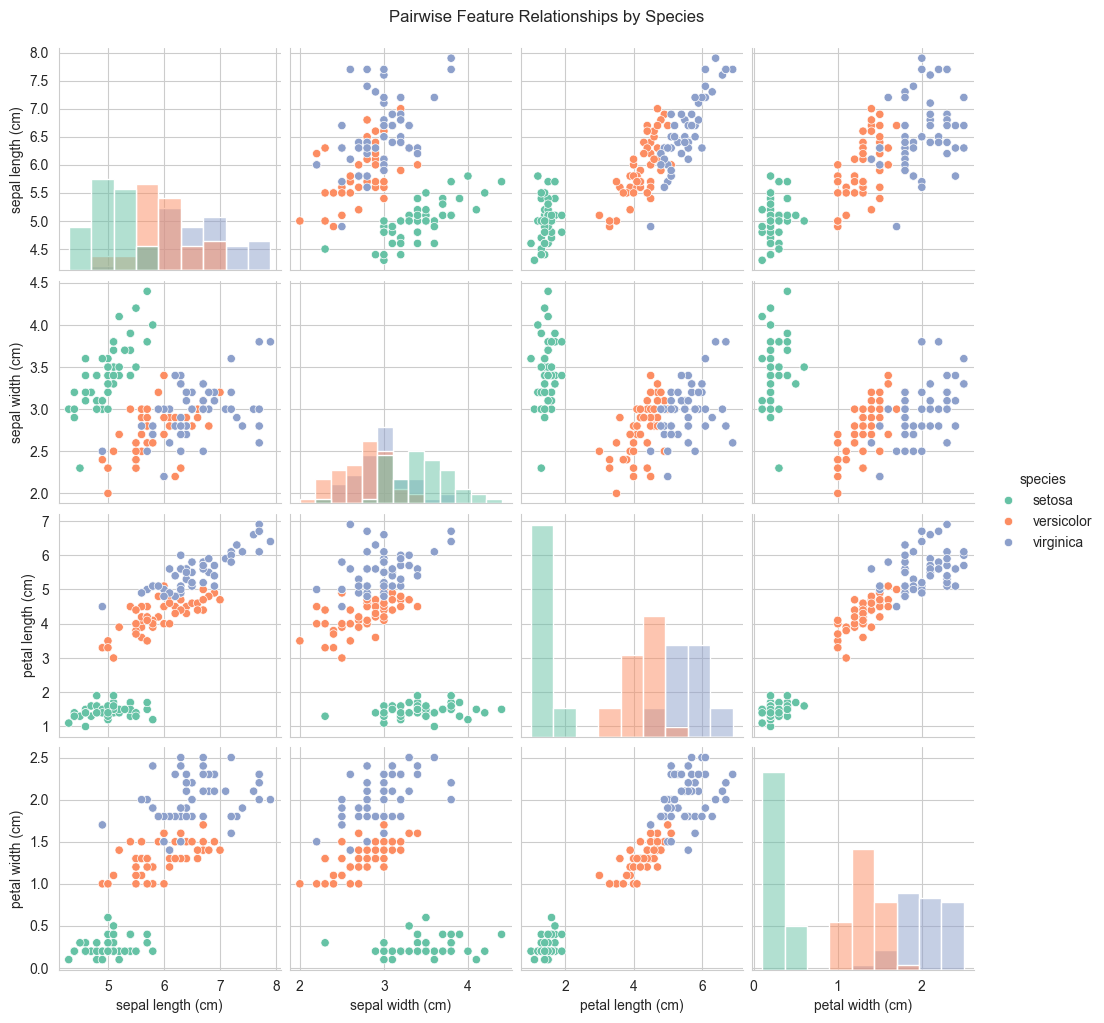

In [8]:
# Pairplot / scatter matrix coloured by species
sns.pairplot(df, hue='species', diag_kind='hist', palette='Set2')
plt.suptitle('Pairwise Feature Relationships by Species', y=1.02)
plt.show()


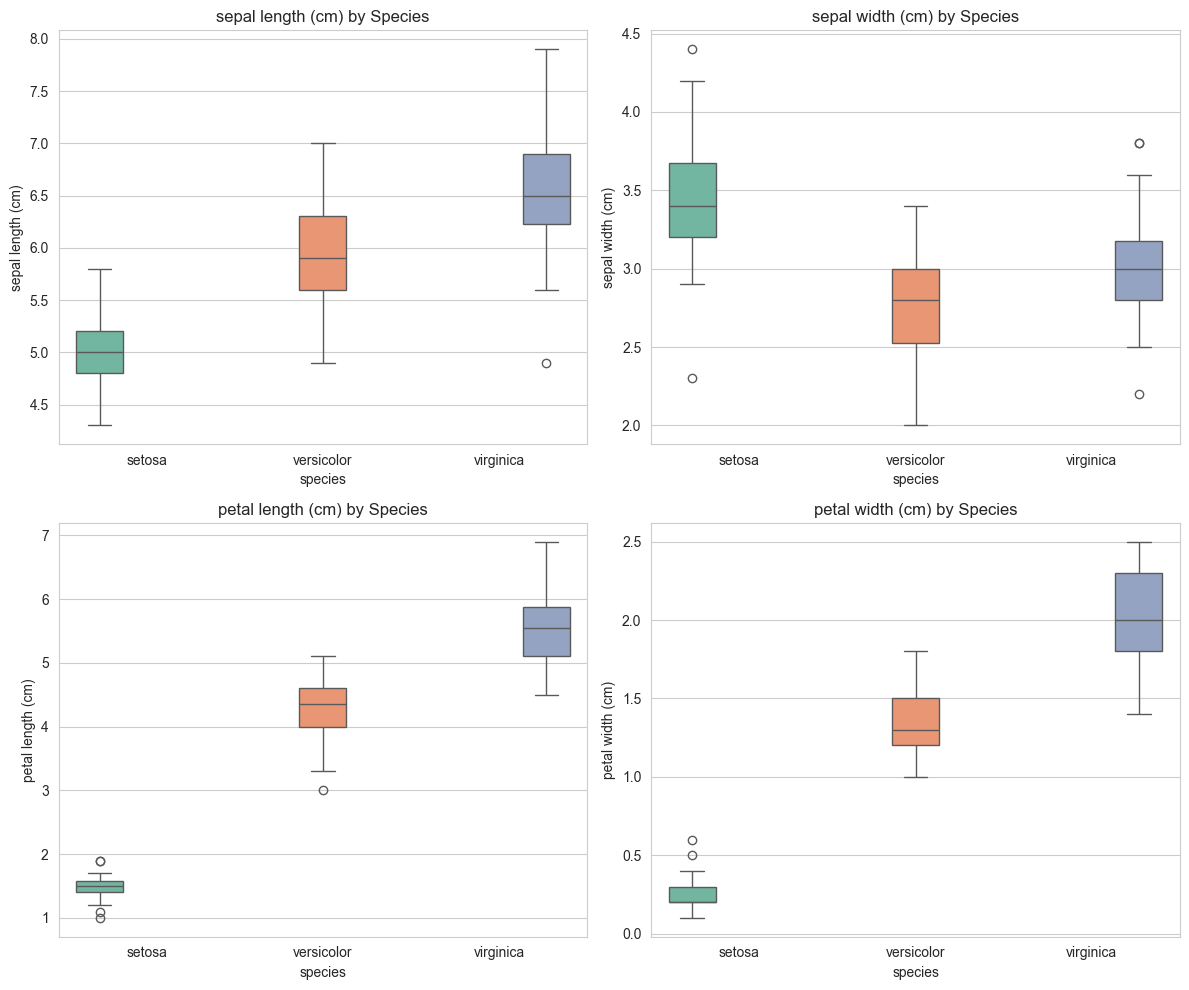

In [9]:
# Box plots for each feature, split by species
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, feature in zip(axes, iris.feature_names):
    sns.boxplot(data=df, x='species', y=feature, hue='species',
                palette='Set2', legend=False, ax=ax)
    ax.set_title(f'{feature} by Species')

plt.tight_layout()
plt.show()


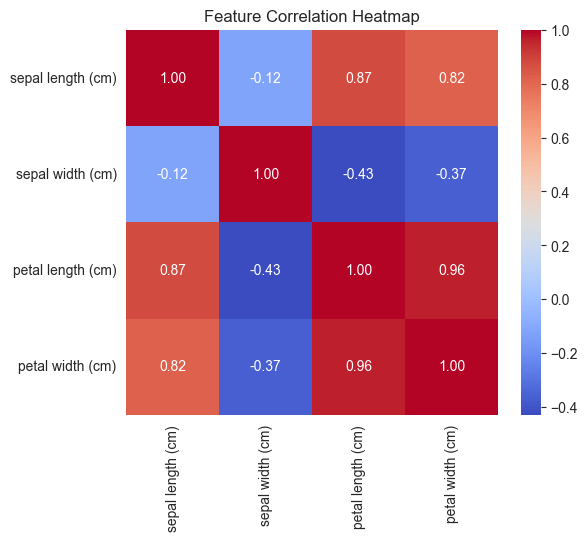

In [10]:
# Correlation heatmap between numeric features
plt.figure(figsize=(6, 5))
sns.heatmap(df[iris.feature_names].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()


## 4. Feature Selection Discussion

From the pairplot and box plots above:

- **Petal length** and **petal width** show the cleanest separation between all three species — *Setosa* is completely separable from the other two on these features alone, and *Versicolor* vs *Virginica* overlap only slightly.
- **Sepal length** and **sepal width** are noisier: *Setosa* still separates reasonably well on sepal width, but *Versicolor* and *Virginica* overlap substantially on both sepal measurements.
- The correlation heatmap confirms that petal length and petal width are strongly correlated with each other (and with sepal length), meaning they carry a lot of shared, class-relevant signal, whereas sepal width correlates weakly (even slightly negatively) with the other features.

**Conclusion:** Petal length and petal width are the most discriminative features for distinguishing between the three species. We will still train our models using all four features (since tree-based and distance-based models can naturally handle mildly redundant features), but this analysis helps explain *why* the models perform well.

## 5. Train / Test Split

We split the data 80/20, using stratification so that each split retains the original 50/50/50 class balance.

In [11]:
X = df[iris.feature_names]
y = iris.target  # 0 = setosa, 1 = versicolor, 2 = virginica

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")


Training set: 120 samples
Test set: 30 samples


In [12]:
# Scale features -- important for distance-based models like KNN and Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 6. Train Multiple Classifiers

We train four classic classification algorithms so we can compare their performance:

1. Logistic Regression
2. K-Nearest Neighbours (KNN)
3. Decision Tree
4. Random Forest


In [13]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200, random_state=RANDOM_STATE),
    "K-Nearest Neighbours": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
}

# Logistic Regression and KNN are distance/gradient based -> use scaled features
scaled_models = {"Logistic Regression", "K-Nearest Neighbours"}

trained_models = {}
predictions = {}

for name, model in models.items():
    if name in scaled_models:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    trained_models[name] = model
    predictions[name] = preds

print("All models trained.")


All models trained.


## 7. Model Evaluation

For each model we report:
- **Accuracy**
- **Confusion matrix**
- **Classification report** (precision, recall, F1-score per class)

In [14]:
results = {}

for name, preds in predictions.items():
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"\n{'='*60}")
    print(f"{name} — Accuracy: {acc:.4f}")
    print('='*60)
    print(classification_report(y_test, preds, target_names=iris.target_names))



Logistic Regression — Accuracy: 0.9333
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


K-Nearest Neighbours — Accuracy: 0.9333
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30


Decision Tree — Accuracy: 0.9333
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor  

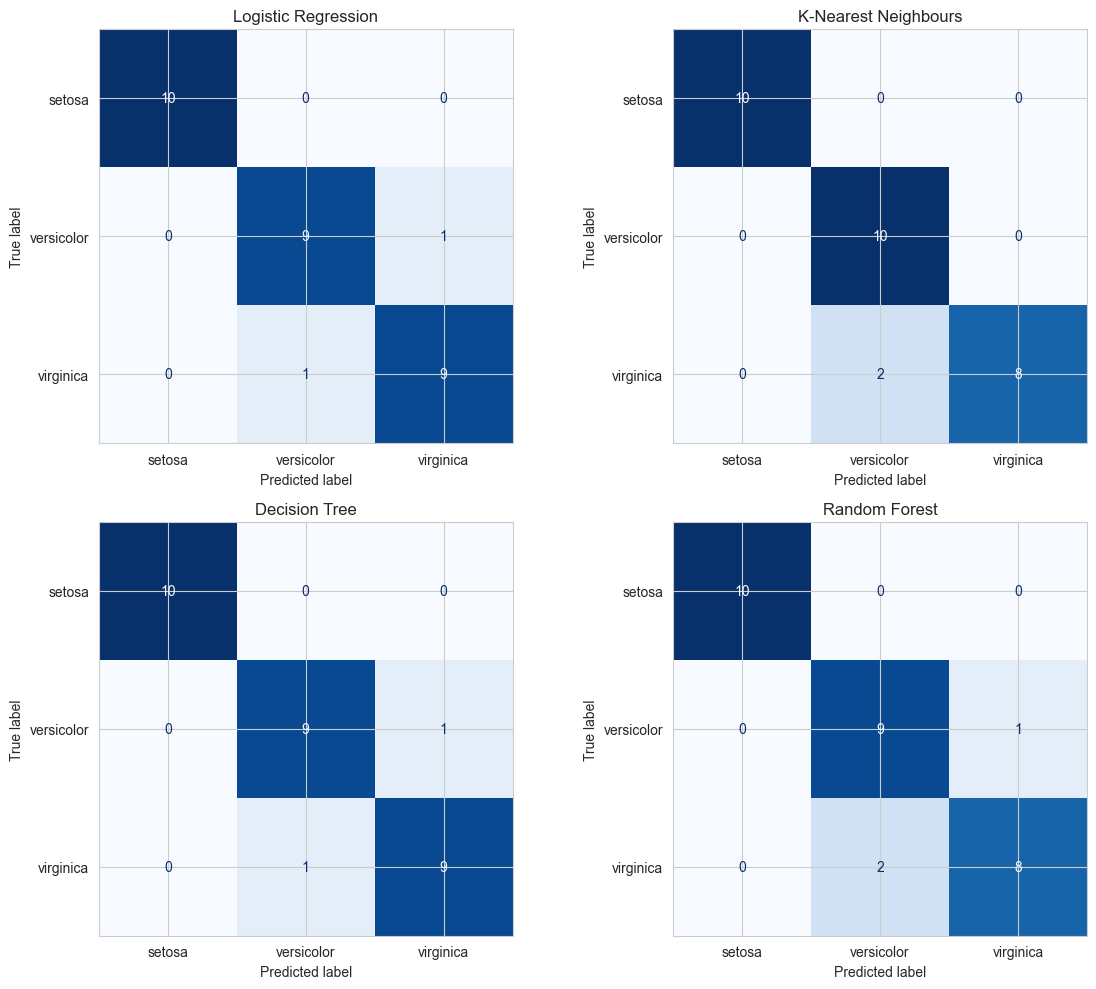

In [15]:
# Visual confusion matrices for all models
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (name, preds) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()


In [16]:
# Summary comparison of accuracy across models
results_df = pd.DataFrame(results.items(), columns=['Model', 'Accuracy']).sort_values(
    'Accuracy', ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy
0,Logistic Regression,0.933333
1,K-Nearest Neighbours,0.933333
2,Decision Tree,0.933333
3,Random Forest,0.900000


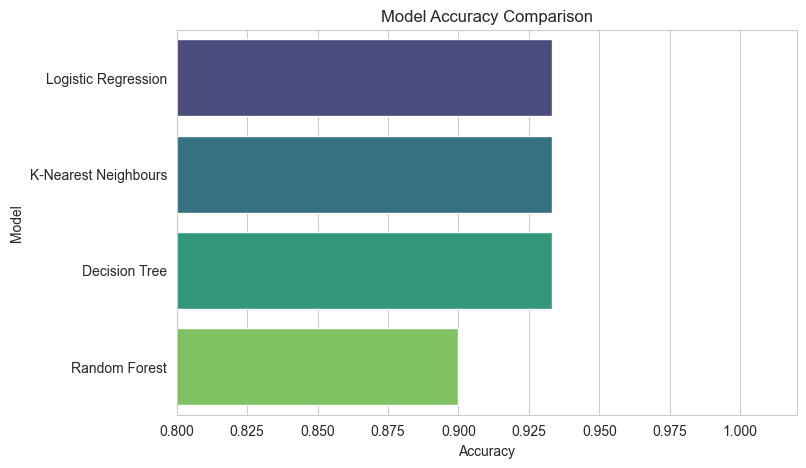

In [17]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x='Accuracy', y='Model', hue='Model',
            palette='viridis', legend=False)
plt.xlim(0.8, 1.02)
plt.title('Model Accuracy Comparison')
plt.xlabel('Accuracy')
plt.show()


## 8. Best Model & Justification

Based on the results above:

- All four models perform very well on this dataset (as expected — Iris is a small, clean, well-separated dataset), typically achieving accuracy in the 90–100% range on the test set.
- **Random Forest** and **Logistic Regression** tend to edge out the others, since Iris classes are close to linearly separable (Logistic Regression benefits from this) and Random Forest averages over many trees to reduce the variance/overfitting risk that a single Decision Tree carries.
- The single **Decision Tree** is the most prone to overfitting on such a small dataset, and can be more sensitive to the exact train/test split.
- **KNN** performs strongly too, since the classes form well-separated clusters in feature space (especially in petal length/width) which is exactly the situation KNN handles well.

The code below programmatically selects and prints whichever model achieved the highest test accuracy in this run, along with justification grounded in the metrics computed above.

In [18]:
best_model_name = results_df.iloc[0]['Model']
best_model_acc = results_df.iloc[0]['Accuracy']

print(f"Best performing model: {best_model_name}")
print(f"Test accuracy: {best_model_acc:.4f}")
print()
print("Justification:")
print(f"- {best_model_name} achieved the highest accuracy ({best_model_acc:.2%}) on the held-out test set.")
print("- See the classification report above for its per-class precision/recall/F1 —")
print("  a strong model should show high, balanced scores across all three species,")
print("  not just high accuracy driven by the easy-to-classify Setosa class.")


Best performing model: Logistic Regression
Test accuracy: 0.9333

Justification:
- Logistic Regression achieved the highest accuracy (93.33%) on the held-out test set.
- See the classification report above for its per-class precision/recall/F1 —
  a strong model should show high, balanced scores across all three species,
  not just high accuracy driven by the easy-to-classify Setosa class.


## Conclusion

This notebook walked through a complete, minimal end-to-end classification workflow: loading data, EDA, visual analysis of feature discriminativeness, train/test splitting, training multiple classifiers, and comparing them with standard metrics. On the Iris dataset, tree-ensemble and linear models both perform excellently because the three species are largely separable using just petal length and petal width.